# Подготовка данных (Pipeline)

In [10]:
from db.core import db_to_csv

db_to_csv()

2026-05-04 20:47:12.690 | INFO     | db.core:db_to_csv:72 - Таблица gold_cost экспортирована в CSV.
2026-05-04 20:47:12.730 | INFO     | db.core:db_to_csv:72 - Таблица sliver_cost экспортирована в CSV.
2026-05-04 20:47:12.761 | INFO     | db.core:db_to_csv:72 - Таблица copper_cost экспортирована в CSV.
2026-05-04 20:47:12.802 | INFO     | db.core:db_to_csv:72 - Таблица gold_predict_cost экспортирована в CSV.
2026-05-04 20:47:12.841 | INFO     | db.core:db_to_csv:72 - Таблица sliver_predict_cost экспортирована в CSV.
2026-05-04 20:47:12.880 | INFO     | db.core:db_to_csv:72 - Таблица copper_predict_cost экспортирована в CSV.
2026-05-04 20:47:12.987 | INFO     | db.core:db_to_csv:72 - Таблица gold_news экспортирована в CSV.
2026-05-04 20:47:13.020 | INFO     | db.core:db_to_csv:72 - Таблица sliver_news экспортирована в CSV.
2026-05-04 20:47:13.056 | INFO     | db.core:db_to_csv:72 - Таблица copper_news экспортирована в CSV.
2026-05-04 20:47:13.084 | INFO     | db.core:db_to_csv:72 - Табл

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import pickle

def load_and_prepare_dataset(metal_name):
    # Загружаем цены и новости
    cost_file = f'data/{metal_name}_cost.csv'
    news_file = f'data/{metal_name}_news.csv'

    df_cost = pd.read_csv(cost_file)
    df_cost['date'] = pd.to_datetime(df_cost['date']).dt.date
    # Группируем цены по дням, если есть дубликаты
    df_cost = df_cost.groupby('date')[['open', 'high', 'low', 'close']].mean().reset_index()

    df_news = pd.read_csv(news_file)
    df_news['date'] = pd.to_datetime(df_news['date']).dt.date

    # Загрузка модели SVM для тональности (0 - Negative, 1 - Neutral, 2 - Positive)
    pipeline_svm = joblib.load('predict_model/svm_sentiment_pipeline.pkl')

    # Предсказание тональности новостей
    df_news = df_news.dropna(subset=['full_text'])
    sentiments = pipeline_svm.predict(df_news['full_text'].astype(str))

    # Переводим (0, 1, 2) в (-1, 0, 1)
    sentiment_map = {0: -1, 1: 0, 2: 1}
    df_news['sentiment'] = [sentiment_map[s] for s in sentiments]

    # Усредняем сентимент за день, если новостей несколько, и округляем к ближайшему классу
    daily_sentiment = df_news.groupby('date')['sentiment'].mean().round().astype(int).reset_index()

    # Объединяем, если новостей нет - ставим 0
    df_combined = pd.merge(df_cost, daily_sentiment, on='date', how='left')
    df_combined['sentiment'] = df_combined['sentiment'].fillna(0)

    df_combined.set_index('date', inplace=True)
    return df_combined


In [12]:
# Загружаем датасет для золота
df_gold = load_and_prepare_dataset('gold')
display(df_gold.head())


,open,high,low,close,sentiment
date,,,,,
2019-04-11,2702.0,2702.0,2685.0,2689.0,0.0
2019-04-12,2683.5,2683.5,2670.0,2677.5,0.0
2019-04-15,2658.5,2660.5,2656.0,2656.0,0.0
2019-04-16,2655.0,2656.0,2640.0,2642.0,0.0
2019-04-17,2630.5,2633.5,2621.5,2623.0,0.0


# Обучение LSTM модели на датасете цен + тональности

In [13]:
def train_lstm_pipeline(df, metal_name, timesteps=30):
    features = ['open', 'high', 'low', 'close', 'sentiment']
    data = df[features].copy()

    train_size = len(data) - 60
    df_train = data.iloc[:train_size].copy()
    df_test = data.iloc[train_size:].copy()

    scaler = MinMaxScaler()
    df_train_scaled = pd.DataFrame(scaler.fit_transform(df_train), columns=features, index=df_train.index)

    df_combined_scaled = pd.DataFrame(scaler.transform(data), columns=features, index=data.index)

    def make_sequences(dataset, timesteps):
        X, y = [], []
        values = dataset.values
        for i in range(len(values) - timesteps):
            X.append(values[i:i+timesteps])
            # Предсказываем закрытие или все 4 цены. Возьмем 4 цены.
            y.append(values[i+timesteps, :4])
        return np.array(X), np.array(y)

    X_train, y_train = make_sequences(df_train_scaled, timesteps)

    # Подготовка теста
    X_test_all, y_test_all = make_sequences(df_combined_scaled, timesteps)
    X_test = X_test_all[-len(df_test):]
    y_test = y_test_all[-len(df_test):]

    model = Sequential([
        LSTM(64, input_shape=(timesteps, len(features)), return_sequences=True),
        Dropout(0.15),
        LSTM(32, return_sequences=False),
        Dropout(0.15),
        Dense(16, activation='relu'),
        Dense(4)  # 4 выхода (open, high, low, close)
    ])

    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.7, patience=5, min_lr=0.00001)

    print(f"Обучение LSTM для {metal_name}...")
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Сохраняем модель
    save_dir = Path("predict_model/models")
    save_dir.mkdir(parents=True, exist_ok=True)

    bundle = {
        "model_json": model.to_json(),
        "model_weights": model.get_weights(),
        "scaler": scaler,
        "timesteps": timesteps,
        "features": features,
    }

    with open(save_dir / f"{metal_name}_lstm_bundle.pkl", "wb") as f:
        pickle.dump(bundle, f)

    print(f"Модель сохранена в {save_dir}/{metal_name}_lstm_bundle.pkl")
    return model, history, scaler, X_test, y_test


In [14]:
model, history, scaler, X_test, y_test = train_lstm_pipeline(df_gold, 'gold')


Обучение LSTM для gold...
Epoch 1/100


D:\SUAI\Diplom\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0325 - mae: 0.1318 - val_loss: 0.0395 - val_mae: 0.1714 - learning_rate: 5.0000e-04
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0038 - mae: 0.0458 - val_loss: 0.0148 - val_mae: 0.0939 - learning_rate: 5.0000e-04
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0024 - mae: 0.0352 - val_loss: 0.0120 - val_mae: 0.0837 - learning_rate: 5.0000e-04
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0023 - mae: 0.0337 - val_loss: 0.0095 - val_mae: 0.0735 - learning_rate: 5.0000e-04
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0022 - mae: 0.0335 - val_loss: 0.0138 - val_mae: 0.0943 - learning_rate: 5.0000e-04
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0020 - mae: 0.0321 - val_loss: 0.0100 - val_mae: 0.0767 - learning_rate: 5.0000e-04
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0019 - mae: 0.0308 - val_loss: 0.0061 - val_mae: 0.0605 - learning_rate: 5

# Оценка и визуализация результатов

In [15]:
def plot_results(model, history, scaler, X_test, y_test, features=['open', 'high', 'low', 'close', 'sentiment']):
    pred_scaled = model.predict(X_test)

    # Для inverse_transform нужен массив той же размерности (5 фичей)
    # y_test и pred_scaled содержат только 4 фичи (open, high, low, close)
    pred_full = np.zeros((pred_scaled.shape[0], len(features)))
    pred_full[:, :4] = pred_scaled
    pred_real = scaler.inverse_transform(pred_full)[:, :4]

    y_test_full = np.zeros((y_test.shape[0], len(features)))
    y_test_full[:, :4] = y_test
    y_test_real = scaler.inverse_transform(y_test_full)[:, :4]

    from sklearn.metrics import mean_absolute_error

    columns = features[:4]
    mae_dict = {}
    rmse_dict = {}

    for i, col in enumerate(columns):
        mae = mean_absolute_error(y_test_real[:, i], pred_real[:, i])
        rmse = np.sqrt(np.mean((y_test_real[:, i] - pred_real[:, i]) ** 2))
        mae_dict[col] = mae
        rmse_dict[col] = rmse
        print(f"{col:6} | MAE: {mae:8.4f} | RMSE: {rmse:8.4f}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Real vs Predicted', fontsize=14, fontweight='bold')

    for idx, col in enumerate(columns):
        ax = axes[idx // 2, idx % 2]
        ax.plot(range(len(y_test_real)), y_test_real[:, idx], label='Real', linewidth=2, marker='o', markersize=4)
        ax.plot(range(len(pred_real)), pred_real[:, idx], label='Predicted', linewidth=2, marker='s', markersize=4, alpha=0.7)
        ax.fill_between(range(len(y_test_real)), y_test_real[:, idx], pred_real[:, idx], alpha=0.2)
        ax.set_title(f'{col} (MAE: {mae_dict[col]:.4f}, RMSE: {rmse_dict[col]:.4f})')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # График обучения
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_ylabel('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_title('Model Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['mae'], label='Train MAE')
    ax2.plot(history.history['val_mae'], label='Val MAE')
    ax2.set_ylabel('MAE')
    ax2.set_xlabel('Epoch')
    ax2.set_title('Model MAE')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
open   | MAE: 1651.1479 | RMSE: 1701.4711
high   | MAE: 821.5541 | RMSE: 907.5702
low    | MAE: 311.1232 | RMSE: 461.9461
close  | MAE: 1393.0682 | RMSE: 1454.6050


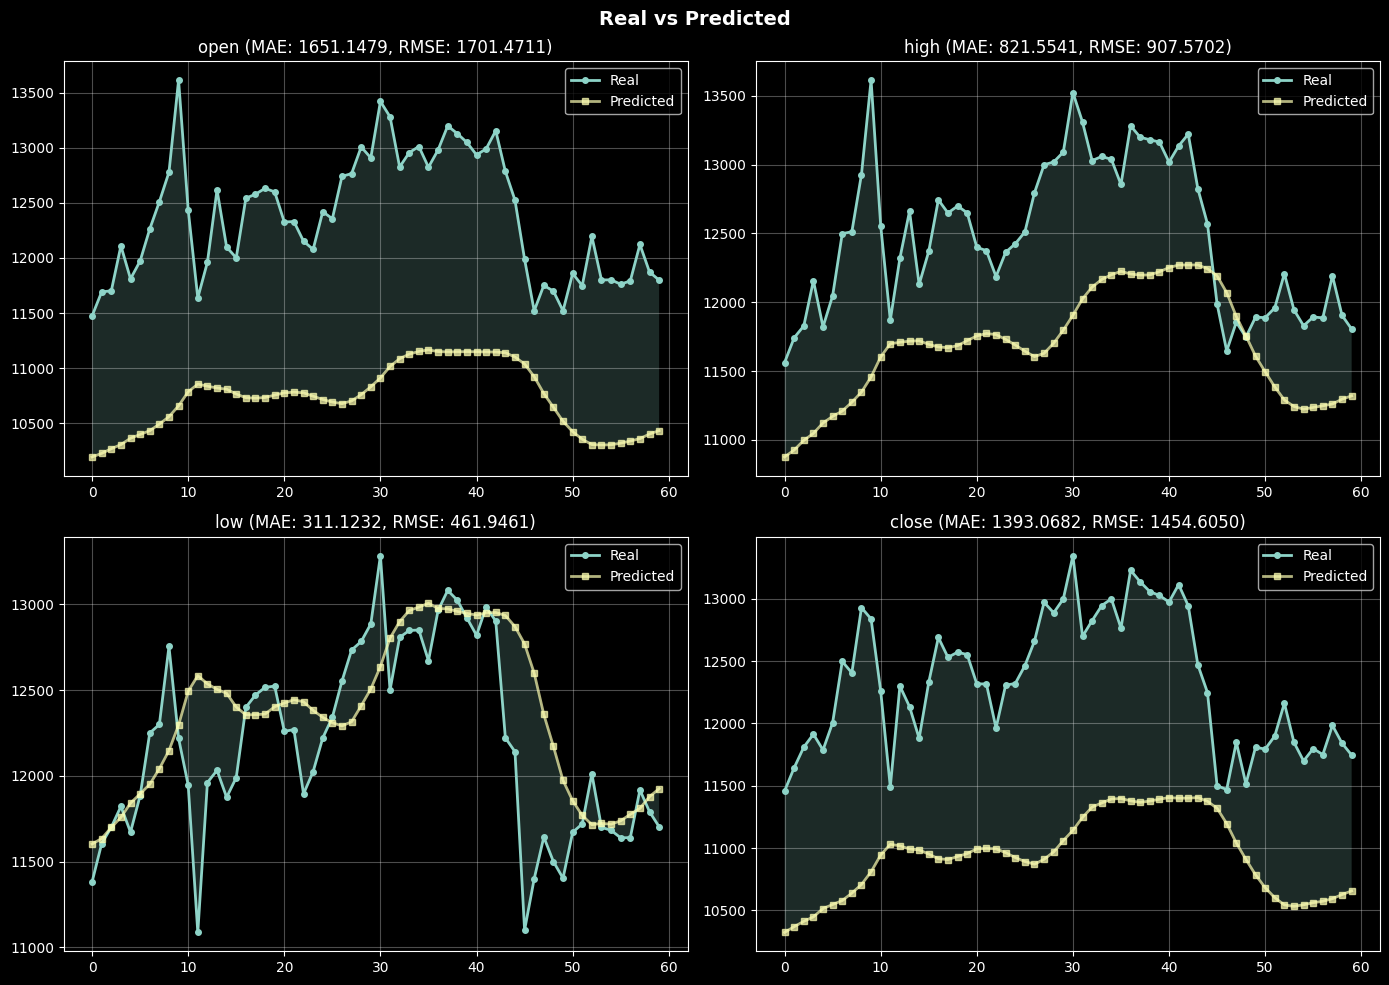

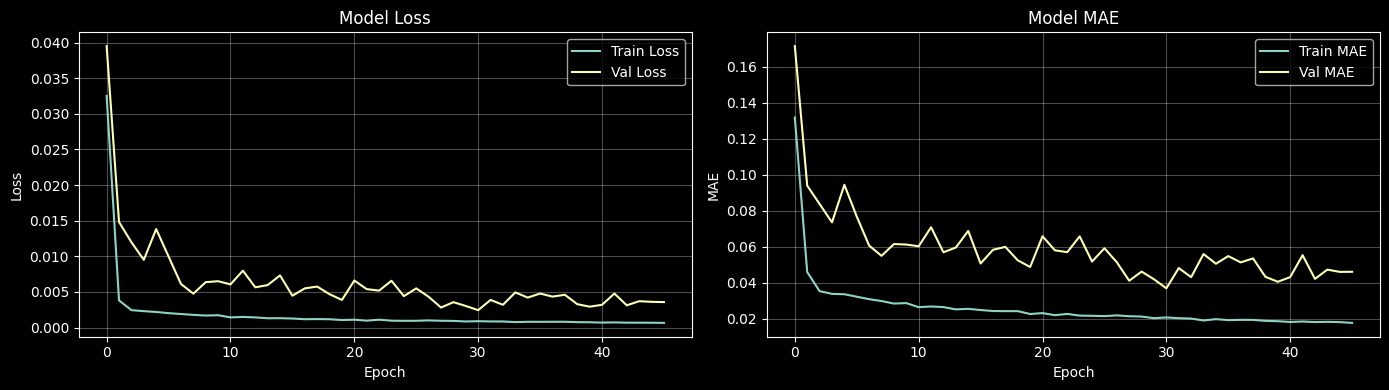

In [16]:
plot_results(model, history, scaler, X_test, y_test)
